# Metrics Walkthrough Notebook
This compact notebook demonstrates generating data, processing it, visualizing results, and adding unit tests runnable in VS Code.

In [1]:
# Setup and Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
# Small Section: Data Generation
N = 100
x = np.linspace(0, 10, N)
noise = 0.5 * np.random.randn(N)
y = 2.0 * x + 3.0 + noise
df = pd.DataFrame({"x": x, "y": y})
print(df.head())

         x         y
0  0.00000  3.248357
1  0.10101  3.132888
2  0.20202  3.727885
3  0.30303  4.367576
4  0.40404  3.691004


In [3]:
# Small Section: Processing Function
def normalize_and_metrics(series: pd.Series):
    s = series.astype(float)
    mu = float(s.mean())
    sigma = float(s.std(ddof=1))
    if sigma == 0:
        norm = s - mu
    else:
        norm = (s - mu) / sigma
    return norm, {"mean": mu, "variance": float(s.var(ddof=1))}

norm_y, stats = normalize_and_metrics(df["y"])
df["y_norm"] = norm_y
print("Stats:", stats)

Stats: {'mean': 12.948076741302955, 'variance': 34.79332984051334}


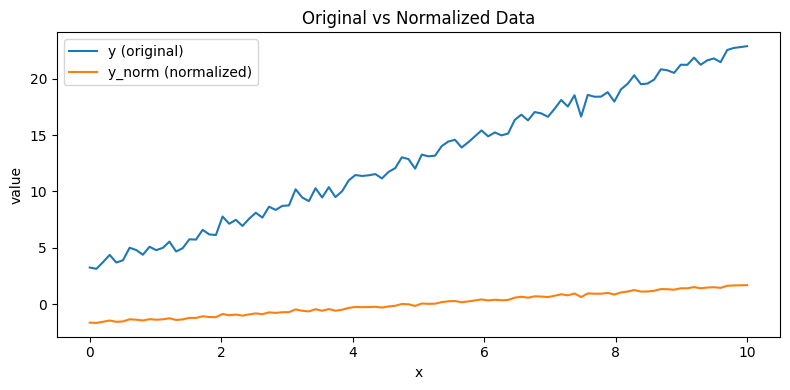

In [4]:
# Small Section: Visualization
plt.figure(figsize=(8, 4))
plt.plot(df["x"], df["y"], label="y (original)")
plt.plot(df["x"], df["y_norm"], label="y_norm (normalized)")
plt.xlabel("x")
plt.ylabel("value")
plt.title("Original vs Normalized Data")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Unit Tests (pytest) Integration in VS Code
%%writefile tests/test_normalize.py
import pandas as pd
from examples.metrics_walkthrough_support import normalize_and_metrics if False else None
def normalize_and_metrics(series: pd.Series):
    s = series.astype(float)
    mu = float(s.mean())
    sigma = float(s.std(ddof=1))
    if sigma == 0:
        norm = s - mu
    else:
        norm = (s - mu) / sigma
    return norm, {"mean": mu, "variance": float(s.var(ddof=1))}
def test_normalization_basic():
    s = pd.Series([1.0, 2.0, 3.0])
    norm, stats = normalize_and_metrics(s)
    assert abs(stats["mean"] - 2.0) < 1e-9
    assert abs(stats["variance"] - 1.0) < 1e-9
    assert abs(float(norm.mean())) < 1e-9

SyntaxError: invalid syntax (1184203472.py, line 4)

In [ ]:
# Run and Capture Output in VS Code Terminal
print("Summary stats:")
print(stats)
print("\nTo run tests from VS Code terminal:")
print("pytest -q")